
# Оцінка та вдосконалення моделі


<h2>Мета</h2>

Ознайомитись з методами оцінки та вдосконалення регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Розділяти дані на навчальну та тестову вибірки
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі прогнозування за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Запишіть дані у два датафрейми: предиктори (x_data) та відгуки (y_data). Випадковим чином розділіть дані на навчальні та тестові (використайте 20% загального набору в якості тестових даних).
2. Побудуйте модель лінійної одномірної регресії для одного з предикторів, використовуючи навчальні дані. Знайдіть R^2 на навчальних та тестових даних. Чому вони різні і на який з них треба орієнтуватись при виборі моделі?
3. Побудуйте кілька поліноміальних моделей різних ступенів для того ж предиктора. Знайдіть R^2 цих моделей на тестових даних. Яка з моделей краща? При якому ступені полінома спостерігається перенавчання?
4. Побудуйте модель гребеневої регресії для двох найкращих предикторів. Параметр alpha повинен бути встановлений на 10. Обчисліть R^2.
5. Виконайте пошук по сітці для параметра alpha та параметра нормалізації, а потім побудуйте модель, використавши найкращі значення параметрів.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Запишіть дані у два датафрейми: предиктори (x_data) та відгуки (y_data). Випадковим чином розділіть дані на навчальні та тестові (використайте 20% загального набору в якості тестових даних).</p>
</div>


Зчитую дані з файлу у датафрейм


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

path = 'data/clean_data.csv'
df = pd.read_csv(path)
df.head()


,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


Буду використовувати тільки числові дані


In [20]:
df_numeric = df.select_dtypes(include='number').dropna()
df_numeric.head()


,GDP per capita,Population,CO2 emission,Area,Density
0,561.778746,34656032.0,9809.225,652860.0,53.083405
1,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,11834.745230,55599.0,6501.591,200.0,277.995000
4,36988.622030,77281.0,462.042,470.0,164.427660


Записую дані у два датафрейми: предиктори (x_data) та відгуки (y_data).


In [21]:
target = 'CO2 emission'
x_data = df_numeric.drop(target, axis=1)
y_data = df_numeric[target]

print('Предиктори:', x_data.columns.tolist())
print('Кількість записів:', x_data.shape[0])


Предиктори: ['GDP per capita', 'Population', 'Area', 'Density']
Кількість записів: 217


Випадковим чином розділяю дані на навчальні та тестові (20% загального набору в якості тестових даних).


In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.20, random_state=42
)

print('Кількість навчальних записів:', x_train.shape[0])
print('Кількість тестових записів:', x_test.shape[0])


Кількість навчальних записів: 173
Кількість тестових записів: 44


<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель лінійної одномірної регресії для одного з предикторів, використовуючи навчальні дані. Знайдіть R^2 на навчальних та тестових даних. Чому вони різні і на який з них треба орієнтуватись при виборі моделі?</p>
</div>


<p>З попередніх робіт знаю, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>'Population'</li>
    <li>'Area'</li>
</ul>
При цьому одномірна модель для ознаки 1 була кращою. Тому будуватиму моделі, використовуючи саме цю ознаку як предиктор.

<p>Створюю об’єкт лінійної регресії та навчаю модель</p>


In [23]:
feature = 'Population'

lr = LinearRegression()
lr.fit(x_train[[feature]], y_train)

print('Вільний член:', lr.intercept_)
print('Коефіцієнт:', lr.coef_[0])


Вільний член: -12265.108263394068
Коефіцієнт: 0.004597297886313173


Обчислюю R^2  на навчальних та тестових даних:


In [24]:
linear_train_r2 = lr.score(x_train[[feature]], y_train)
linear_test_r2 = lr.score(x_test[[feature]], y_test)

print(f'R^2 на навчальних даних: {linear_train_r2:.4f}')
print(f'R^2 на тестових даних: {linear_test_r2:.4f}')


R^2 на навчальних даних: 0.6926
R^2 на тестових даних: 0.4395


<p>R^2 на навчальних і тестових даних різні, бо модель навчається на одній частині вибірки, а перевіряється на інших спостереженнях, яких вона не бачила під час навчання. Навчальний показник зазвичай оптимістичніший, тоді як тестовий краще показує здатність моделі узагальнювати залежність.</p>
<p>При виборі моделі треба орієнтуватись насамперед на якість на тестових даних. Якщо навчальний R^2 високий, а тестовий значно нижчий або від'ємний, це ознака перенавчання.</p>


<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей різних ступенів для того ж предиктора. Знайдіть R^2 цих моделей на тестових даних. Яка з моделей краща? При якому ступені полінома спостерігається перенавчання?</p>
</div>


Будую поліноміальну модель 2 ступеня, на тестових даних обчислюю R^2


In [25]:
degree = 2
poly_model_2 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
poly_model_2.fit(x_train[[feature]], y_train)

poly2_train_r2 = poly_model_2.score(x_train[[feature]], y_train)
poly2_test_r2 = poly_model_2.score(x_test[[feature]], y_test)

print(f'Поліном 2 ступеня: R^2 train = {poly2_train_r2:.4f}, R^2 test = {poly2_test_r2:.4f}')


Поліном 2 ступеня: R^2 train = 0.7049, R^2 test = 0.2797


Будую поліноміальну модель 3 ступеня, на тестових даних обчислюю R^2


In [26]:
degree = 3
poly_model_3 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
poly_model_3.fit(x_train[[feature]], y_train)

poly3_train_r2 = poly_model_3.score(x_train[[feature]], y_train)
poly3_test_r2 = poly_model_3.score(x_test[[feature]], y_test)

print(f'Поліном 3 ступеня: R^2 train = {poly3_train_r2:.4f}, R^2 test = {poly3_test_r2:.4f}')


Поліном 3 ступеня: R^2 train = 0.9002, R^2 test = -1.1294


Будую поліноміальну модель 4 ступеня, на тестових даних обчислюю R^2


In [27]:
degree = 4
poly_model_4 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
poly_model_4.fit(x_train[[feature]], y_train)

poly4_train_r2 = poly_model_4.score(x_train[[feature]], y_train)
poly4_test_r2 = poly_model_4.score(x_test[[feature]], y_test)

print(f'Поліном 4 ступеня: R^2 train = {poly4_train_r2:.4f}, R^2 test = {poly4_test_r2:.4f}')


Поліном 4 ступеня: R^2 train = 0.9668, R^2 test = -0.1138


Візуалізую моделі (зручно розміщувати всі моделі на одному графіку для обрання найкращої) та показник їх якості (доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі)

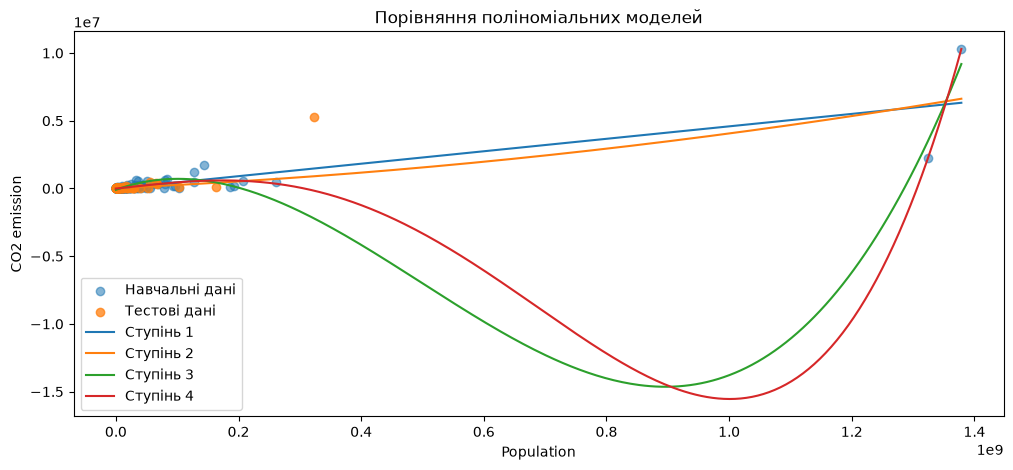

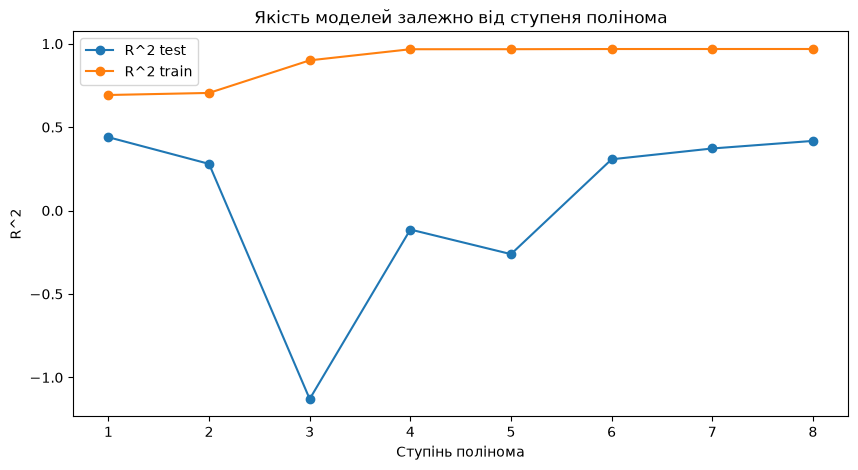

In [37]:
orders = range(1, 9)
poly_results = []

x_plot = np.linspace(x_data[feature].min(), x_data[feature].max(), 300).reshape(-1, 1)

plt.figure(figsize=(12, 5))
plt.scatter(x_train[feature], y_train, alpha=0.55, label='Навчальні дані')
plt.scatter(x_test[feature], y_test, alpha=0.75, label='Тестові дані')

for degree in orders:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linear', LinearRegression())
    ])
    model.fit(x_train[[feature]], y_train)
    y_test_pred = model.predict(x_test[[feature]])
    poly_results.append({
        'degree': degree,
        'train_r2': model.score(x_train[[feature]], y_train),
        'test_r2': model.score(x_test[[feature]], y_test),
        'test_mse': mean_squared_error(y_test, y_test_pred)
    })

    if degree in [1, 2, 3, 4]:
        plt.plot(x_plot.ravel(), model.predict(x_plot), label=f'Ступінь {degree}')

plt.xlabel(feature)
plt.ylabel(target)
plt.title('Порівняння поліноміальних моделей')
plt.legend()
plt.show()

poly_results_df = pd.DataFrame(poly_results)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(poly_results_df['degree'], poly_results_df['test_r2'], marker='o', label='R^2 test')
ax1.plot(poly_results_df['degree'], poly_results_df['train_r2'], marker='o', label='R^2 train')
ax1.set_xlabel('Ступінь полінома')
ax1.set_ylabel('R^2')
ax1.legend(loc='best')
ax1.set_title('Якість моделей залежно від ступеня полінома')
plt.show()

nonlinear_poly_results = poly_results_df[poly_results_df['degree'] >= 2]
best_poly_degree = int(nonlinear_poly_results.loc[nonlinear_poly_results['test_r2'].idxmax(), 'degree'])
best_poly_r2 = float(nonlinear_poly_results['test_r2'].max())
best_overall_degree = int(poly_results_df.loc[poly_results_df['test_r2'].idxmax(), 'degree'])
best_overall_r2 = float(poly_results_df['test_r2'].max())



Серед нелінійних поліноміальних моделей найкращою є модель 8 ступеня, бо вона має найбільший R^2 на тестовій вибірці серед ступенів 2-8. Якщо порівнювати також зі ступенем 1, то проста лінійна модель залишається кращою. Ознаки перенавчання добре видно вже для полінома 3 ступеня: навчальний R^2 різко зростає, але тестовий R^2 стає від'ємним.


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте модель гребеневої регресії для двох найкращих предикторів. Параметр alpha повинен бути встановлений на 10. Обчисліть R^2.</p>
</div>


Будую модель гребеневої регресії, обчислюю R^2


In [29]:
best_features = ['Population', 'Area']

ridge_poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_ridge_pr = ridge_poly.fit_transform(x_train[best_features])
x_test_ridge_pr = ridge_poly.transform(x_test[best_features])

ridge_scaler = StandardScaler()
x_train_ridge_scaled = ridge_scaler.fit_transform(x_train_ridge_pr)
x_test_ridge_scaled = ridge_scaler.transform(x_test_ridge_pr)

print('Кількість поліноміальних ознак:', x_train_ridge_scaled.shape[1])


Кількість поліноміальних ознак: 5


In [30]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(x_train_ridge_scaled, y_train)

ridge_train_r2 = ridge_model.score(x_train_ridge_scaled, y_train)
ridge_test_r2 = ridge_model.score(x_test_ridge_scaled, y_test)

print(f'R^2 гребеневої регресії на навчальних даних: {ridge_train_r2:.4f}')
print(f'R^2 гребеневої регресії на тестових даних: {ridge_test_r2:.4f}')


R^2 гребеневої регресії на навчальних даних: 0.9460
R^2 гребеневої регресії на тестових даних: 0.6658


<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконайте пошук по сітці для параметра alpha та параметра нормалізації, а потім побудуйте модель, використавши найкращі значення параметрів.</p>
</div>


Створюю словник значень параметрів:


In [31]:
parameters = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'scaler': ['passthrough', StandardScaler()]
}
parameters


{'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
 'scaler': ['passthrough', StandardScaler()]}

Створюю об’єкт сітки пошуку параметра гребеневої регресії:


In [32]:
ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

Grid = GridSearchCV(ridge_pipeline, parameters, cv=5, scoring='r2')
Grid


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.001, 0.01, ...], 'scaler': ['passthrough', StandardScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

Підбираю модель:


In [33]:
Grid.fit(x_train[best_features], y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.001, 0.01, ...], 'scaler': ['passthrough', StandardScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

Отримую модель з найкращими параметрами:


In [34]:
BestRidge = Grid.best_estimator_

print('Найкращі параметри:', Grid.best_params_)
print(f'Найкращий середній R^2 на CV: {Grid.best_score_:.4f}')
BestRidge


Найкращі параметри: {'ridge__alpha': 1000, 'scaler': StandardScaler()}
Найкращий середній R^2 на CV: 0.2820


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['Population','Area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


Тестую модель на тестових даних (обчислюю R^2):


In [35]:
best_ridge_test_r2 = BestRidge.score(x_test[best_features], y_test)
print(f'R^2 найкращої гребеневої моделі на тестових даних: {best_ridge_test_r2:.4f}')


R^2 найкращої гребеневої моделі на тестових даних: 0.2680


<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте візуалізації для оцінки якості моделей (лінійної, кращої з поліноміальних та кращої з гребеневих), всі розмістіть на одній координатній сітці для зручного порівняння.</p>
</div>


Використаю метод "predict", щоб спрогнозувати результати, а потім скористаюсь функцією "DistributionPlot", щоб відобразити розподіл прогнозованих результатів для тестових даних порівняно з фактичними для тестових даних.


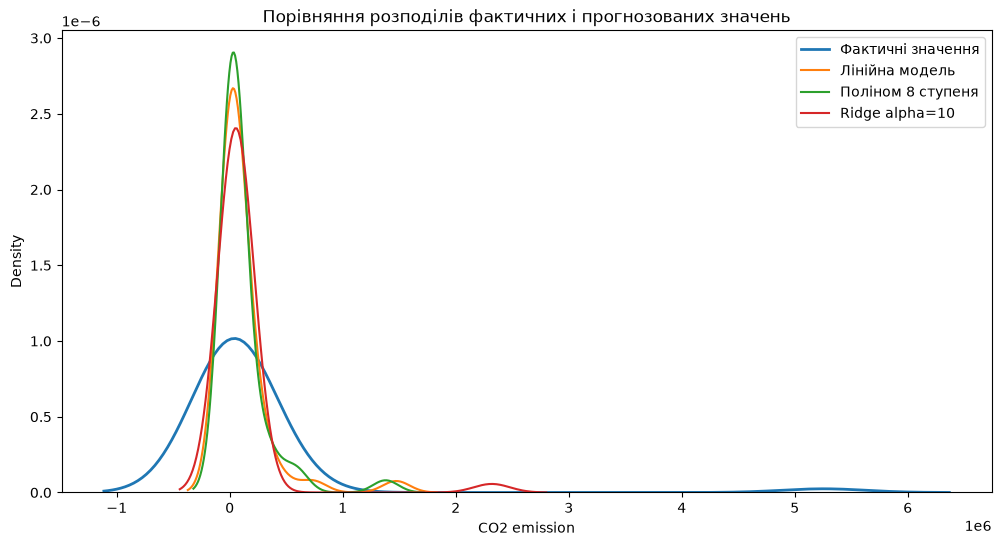

,model,test_r2
2,Ridge alpha=10,0.665765
0,Linear,0.439541
1,Polynomial degree 8,0.417435
3,Ridge GridSearchCV,0.268046


In [40]:
linear_pred = lr.predict(x_test[[feature]])
best_poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_poly_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
best_poly_model.fit(x_train[[feature]], y_train)
poly_pred = best_poly_model.predict(x_test[[feature]])

ridge_grid_test_r2 = BestRidge.score(x_test[best_features], y_test)
if ridge_test_r2 >= ridge_grid_test_r2:
    best_ridge_name = 'Ridge alpha=10'
    best_ridge_r2 = ridge_test_r2
    ridge_pred = ridge_model.predict(x_test_ridge_scaled)
else:
    best_ridge_name = 'Ridge GridSearchCV'
    best_ridge_r2 = ridge_grid_test_r2
    ridge_pred = BestRidge.predict(x_test[best_features])

comparison = pd.DataFrame({
    'Actual': y_test,
    'Linear': linear_pred,
    'Polynomial': poly_pred,
    'Ridge': ridge_pred
})

plt.figure(figsize=(12, 6))
sns.kdeplot(comparison['Actual'], label='Фактичні значення', linewidth=2)
sns.kdeplot(comparison['Linear'], label='Лінійна модель')
sns.kdeplot(comparison['Polynomial'], label=f'Поліном {best_poly_degree} ступеня')
sns.kdeplot(comparison['Ridge'], label=best_ridge_name)
plt.xlabel(target)
plt.title('Порівняння розподілів фактичних і прогнозованих значень')
plt.legend()
plt.show()

model_scores = pd.DataFrame({
    'model': ['Linear', f'Polynomial degree {best_poly_degree}', best_ridge_name, 'Ridge GridSearchCV'],
    'test_r2': [linear_test_r2, best_poly_r2, best_ridge_r2, ridge_grid_test_r2]
})
display(model_scores.sort_values('test_r2', ascending=False))


<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>гребенева регресія з alpha=10 для ознак 'Population' та 'Area' є найкращою моделлю</b> для прогнозування 'CO2 emission' на основі нашого набору даних, оскільки вона отримала найбільше значення R^2 на тестовій вибірці серед перевірених моделей. Проста лінійна модель для 'Population' узагальнює дані краще, ніж нелінійні поліноміальні моделі для цієї ж ознаки, а перенавчання помітне вже зі ступеня 3.</p>


<h2>Виконав студент групи ІП-45 <br> Янов Богдан</h2>
